In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.optimize as opti

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
from misc import newton
from source.normal_modes import * 
import source.global_constants as g 

from publication.publication_figure import PubFigure, LargeFigure, SmallFigure, color
pfig = PubFigure()

folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration\general_ocean_acoustics\modal_theory\basic_modal_features"

# Objectif : illustration des propriétés de la propagation modale dans un guide d'onde de Pekeris 

* Calcul des nombres d'onde horizontaux par résolution de l'équation transcendante associée :

$\tan{k_{zm}D} = - \frac{i \rho_b k_{zm}} {\rho_w k_{zm,b}}$ (1)

avec (Eq. 5.55)

$-ik_{zm,b} = \sqrt{k_{rm}^2 - k_b^2}$

et 

$k_{zm} = \sqrt{k^2 - k_{rm}^2}$

où 

$k = \frac{\omega}{c_w}$ et $k_b = \frac{\omega}{c_b}$. 

Les modes propagatifs correspondent aux modes associées aux zéros réels de l'équation (1). En insérant les relations précédentes dans l'équation transcendante on obtient une équation transcendante en $k_{rm}$ : 

$\tan{D \sqrt{k^2 - k_{rm}^2}} = - \frac{\rho_b}{\rho} \sqrt{\frac{k^2 - k_{rm}^2}{k_{rm}^2 - k_b^2}}$ (2)

* Calcul des angles de propagations des modes :

$\theta_m = \arctan{\frac{k_{zm}}{k_{rm}}}$

* Calcul des vitesses de phase et de groupe associées (Fig.2.28b p. 126) :

$v_{\phi_m} = \frac{\omega}{k_{rm}}$

et 

$v_{g_m} = \frac{d \omega}{d k_{rm}}$

## Résolution de l'équation transcendante 
### Méthode graphique 

On cherche l'indice des points correspondants à l'intersection des courbes définies par chacun des membres de l'équation. 

### Autre option : méthode de Newton 
Cette équation peut être résolue numériquement par la méthode de Newton. Pour rappel, on utilise un développement en série de Taylor 1 de la fonction f : 

$f(x) \approx f(x_0) + f'(x_0)(x-x_0)$ 

le zéro de la fonction f peut être estimé par le 0 de cette approximation. Pour ce faire on construit la suite $(x_n)$ définie par :

$f(x_n) + f'(x_n)(x_{n+1}-x_n) = 0$ 

c'est à dire, 

$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$

Ici la fonction f est la fonction :

$f: x \mapsto \tan{D \sqrt{k^2 - x^2}} + \frac{\rho_b}{\rho} \sqrt{\frac{k^2 - x^2}{x^2 - k_b^2}}$

dont la dérivée est donnée par : 

$f': x \mapsto -(D x)/(sqrt(k^2 - x^2) cos^2(D sqrt(k^2 - x^2)))$


# Etape 0 : définition des paramètres du guide d'onde 

In [2]:
depth = 100.0  # m
max_range_km = 50  # km

# Water
c_water = g.c0
rho_water = g.rho_w  # kg/m^3

# Sediment (Pekeris pulse)
c_sediment = 1600.0  # m/s
rho_sediment = 1500.0  # kg/m^3
alpha_sediment = 0.2  # dB/lambda

# c_sediment = 1800.0  # m/s
# rho_sediment = 1800.0  # kg/m^3
# alpha_sediment = 0.2  # dB/lambda

(-10.0, 10.0)

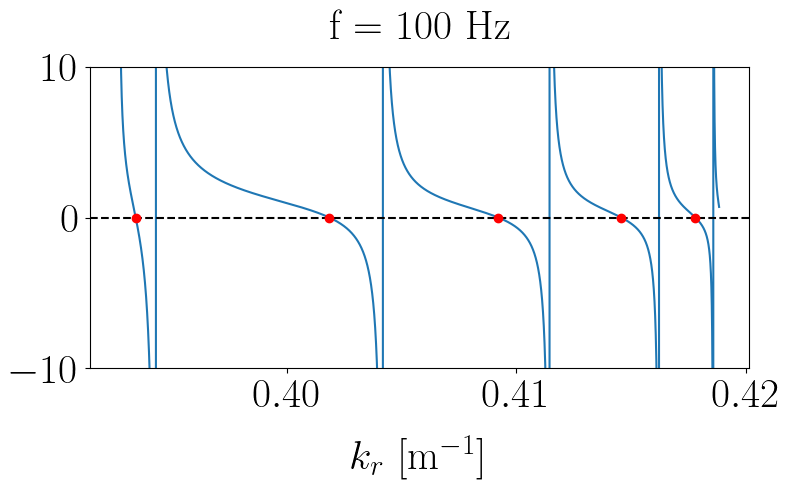

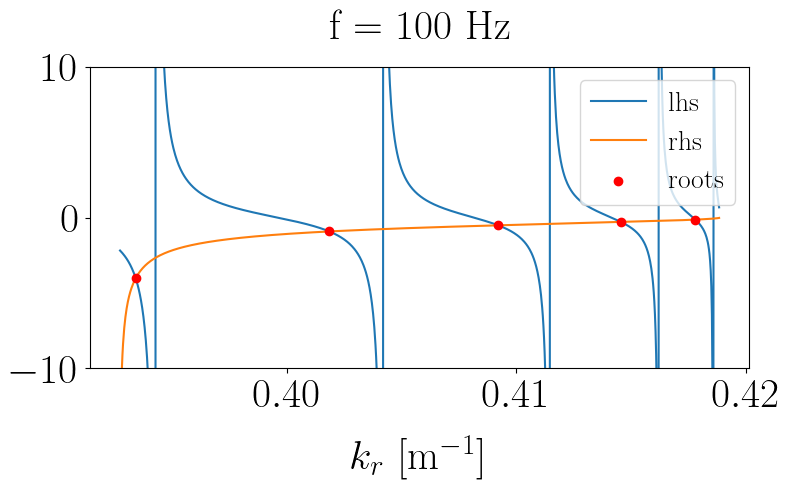

In [3]:
# Réprésentation du membre gauche de l'équation transcendante (2)
eq_1_lhs = lambda kr, omega: np.tan(depth * np.sqrt((omega / c_water) ** 2 - kr**2))
# Réprésentation du membre droit de l'équation transcendante (2)
eq_1_rhs = lambda kr, omega: - (rho_water / rho_sediment) * np.sqrt(((omega / c_water) ** 2 - kr**2) / (kr**2 - (omega / c_sediment) ** 2))

# Fréquence
f = 100 # Hz
omega = 2 * np.pi * f

# Bornes (Cf eq. 2.187) pour avoir des solutions réelles
kr_min = omega / c_sediment * 1.0001
kr_max = omega / c_water * 0.9999
kr = np.linspace(kr_min, kr_max, 100000)

# Find roots (by equating lhs and rhs)
lhs = eq_1_lhs(kr, omega)
rhs = eq_1_rhs(kr, omega)
diff = lhs - rhs

# Find roots by looking for sign changes in diff
diff_shift = np.roll(diff, 1)
idx_roots = (diff < 0) & (diff_shift > 0)
roots = kr[idx_roots]

# Plot diff
plt.figure(figsize=(8, 5))
plt.plot(kr, diff, label=r"$\tan(h\sqrt{(\omega/c_{w})^2 - k_r^2}) + \frac{\rho_{w}}{\rho_{s}}\sqrt{\frac{(\omega/c_{w})^2 - k_r^2}{k_r^2 - (\omega/c_{s})^2}}$")
plt.axhline(0, color='k', linestyle='--')
plt.scatter(roots, diff[idx_roots], color="red", zorder=5, label="Roots")

plt.title(f"f = {f} Hz")
plt.xlabel(r"$k_r$ [m$^{-1}$]")

plt.ylim(-10, 10)


# Plot
kr = np.linspace(kr_min, kr_max, 1000)
plt.figure(figsize=(8, 5))
plt.plot(
    kr, eq_1_lhs(kr, omega), label="lhs"
)  # label=r"$\tan(h\sqrt{(\omega/c_{w})^2 - k_r^2})$"
plt.plot(
    kr, eq_1_rhs(kr, omega), label="rhs"
)  # label=r"$-\frac{\rho_{w}}{\rho_{s}}\sqrt{\frac{(\omega/c_{w})^2 - k_r^2}{k_r^2 - (\omega/c_{s})^2}}$"

# Plot roots
plt.scatter(roots, eq_1_lhs(roots, omega), color='red', zorder=5, label='roots')

plt.legend()
plt.title(f"f = {f} Hz")
plt.xlabel(r"$k_r$ [m$^{-1}$]")

plt.ylim(-10, 10)

In [4]:
# Calcul du nombre de modes propagatif
n_modes = len(roots)
M = int(np.floor(2 * depth / c_water * np.sqrt(1 - (c_water / c_sediment) ** 2) * f + 1/2))

print(f"Number of propagating modes: {n_modes} (theoretical: {M})")

# Fréquence de coupure du dernier mode 
f_c = ((n_modes - 1/2) * c_water) / (2 * depth * np.sqrt(1 - (c_water / c_sediment) ** 2))
print(f"Cut-off frequency of the last mode: {f_c:.2f} Hz")


Number of propagating modes: 5 (theoretical: 5)
Cut-off frequency of the last mode: 96.99 Hz


In [18]:
f = 50
krm, kzm, cpm, cgm, thetam = pekeris_modes(f, c_water, c_sediment, rho_water, rho_sediment, depth)
print(f"f = {f} Hz")
for m, (kr, kz, cp, cg, theta) in enumerate(
    zip(krm[0, :], kzm[0, :], cpm[0, :], cgm[0, :], thetam[0, :])
):
    print(
        f"Mode {m+1}: kr = {kr:.4f} 1/m,  kz = {kz:.4f} 1/m, cp = {cp:.2f} m/s, cg = {cg:.2f} m/s, theta = {theta:.2f} °"
    )

f = 50 Hz
Mode 1: kr = 0.2075 1/m,  kz = 0.0286 1/m, cp = 1514.22 m/s, cg = 1488.86 m/s, theta = 7.86 °
Mode 2: kr = 0.2018 1/m,  kz = 0.0561 1/m, cp = 1556.82 m/s, cg = 1463.78 m/s, theta = 15.53 °


In [19]:
fmin = 0.1
fmax = 100
df = 0.05
f = np.arange(fmin, fmax + df, df)

In [20]:
r_max = 30 * 1e3 
T_ir = pekeris_ir_duration(
    f, c_water, c_sediment, rho_water, rho_sediment, r_max, depth
)
print(f"Duration of the impulse response at {r_max/1e3} km: {T_ir:.2f} s")

Duration of the impulse response at 30.0 km: 1.95 s


In [21]:
krm, kzm, cpm, cgm, thetam = pekeris_modes(f, c_water, c_sediment, rho_water, rho_sediment, depth)

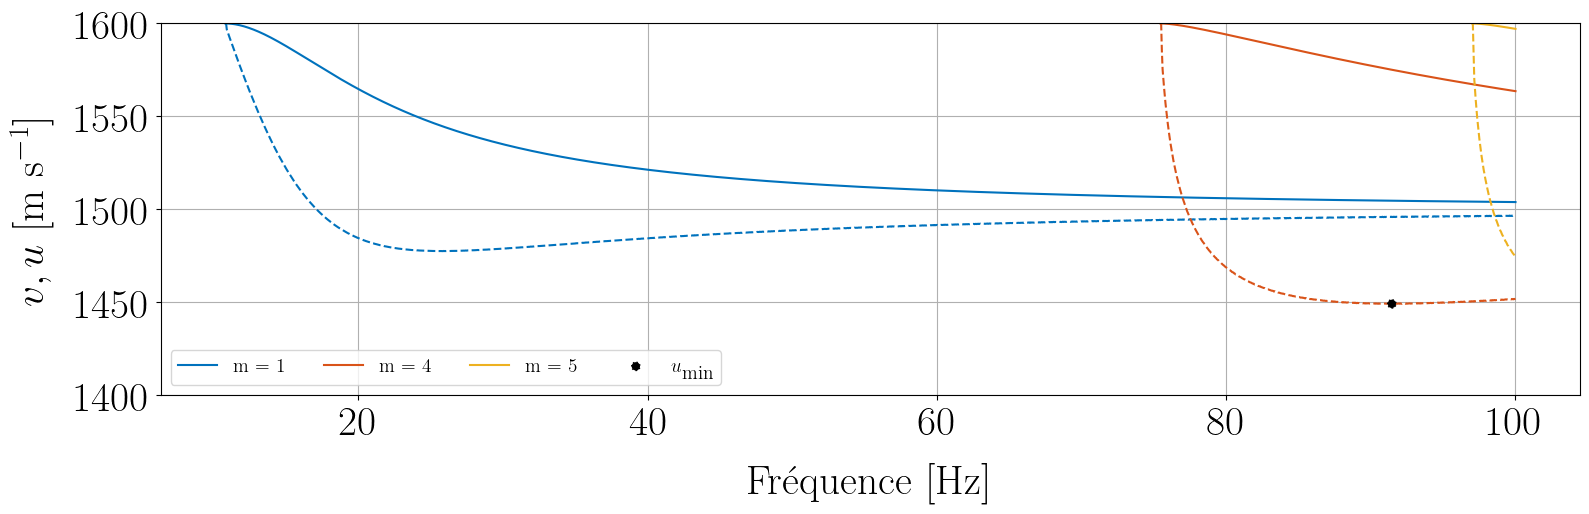

In [22]:
# Plot dispersion curves
lfig = LargeFigure(legend_fontsize=14)

# plt.figure(figsize=(8, 5))
# modes_plot = range(4)
# nmodes = 5
# modes_plot = np.arange(0, krm.shape[1]+1, 1)[::max(1, int(krm.shape[1]/nmodes))][:nmodes]
# modes_plot = np.array([0, 1, 2,  krm.shape[1] - 1])

# All modes
modes_plot = range(krm.shape[1])[::5]
# ensure last mode is included
if modes_plot[-1] != krm.shape[1] - 1:
    modes_plot = np.append(modes_plot, krm.shape[1] - 1)
# Ensure mode associated with minimum group speed is included
min_cg_idx_flat = np.nanargmin(cgm)
f_min_cg_idx, mode_min_cg_idx = np.unravel_index(min_cg_idx_flat, cgm.shape)
if mode_min_cg_idx not in modes_plot:
    modes_plot = np.append(modes_plot, mode_min_cg_idx)
modes_plot = np.sort(modes_plot)

nmodes = len(modes_plot)

for im, m in enumerate(modes_plot):
    plt.plot(f, cpm[:, m], color=color(im), label=f"m = {m+1}")  #
for im, m in enumerate(modes_plot):
    plt.plot(
        f, cgm[:, m], color=color(im),  linestyle="--"
    )  # label=r"$u_{" + f"{m+1}" + "}$"

    # # Add cuttoff frequency
    # fc_m = pekeris_cutoff_frequency(m+1, c_water, c_sediment, depth)
    # plt.axvline(x=fc_m, label=fr"$f_c_{m}$", color=color(m), linestyle="-.")

# Highlight minimum group speed
plt.scatter(
    f[f_min_cg_idx],
    cgm[f_min_cg_idx, mode_min_cg_idx],
    color="k",
    linestyle=":",
    label=r"$u_{\textrm{min}}$",
    zorder=10
)


plt.xlabel("Fréquence [Hz]")
plt.ylabel(r"$v, u$ " + r"[m s$^{-1}$]")
# Set grid
plt.grid()
# plt.ylim([np.nanmin(cgm) - 100, 1800])
plt.ylim([1400, 1600])

# Tikz every 10 Hz
# plt.xticks(np.arange(10, 50 + 1, 10))
# plt.yticks(np.arange(1200, 1801, 100))

plt.legend(ncols=4)

fpath = os.path.join(folder_root, f"pekeris_dispersion_curves_D{depth}m.pdf")
plt.savefig(fpath, dpi=300)

In [10]:
# Fréquence de coupure du mode 1
m = 1
fc_1 = pekeris_cutoff_frequency(m, c_water, c_sediment, depth)
print(f"Cut-off frequency of mode {m}: {fc_1:.2f} Hz")

Cut-off frequency of mode 1: 10.78 Hz


ValueError: x and y must have same first dimension, but have shapes (999,) and (1000,)

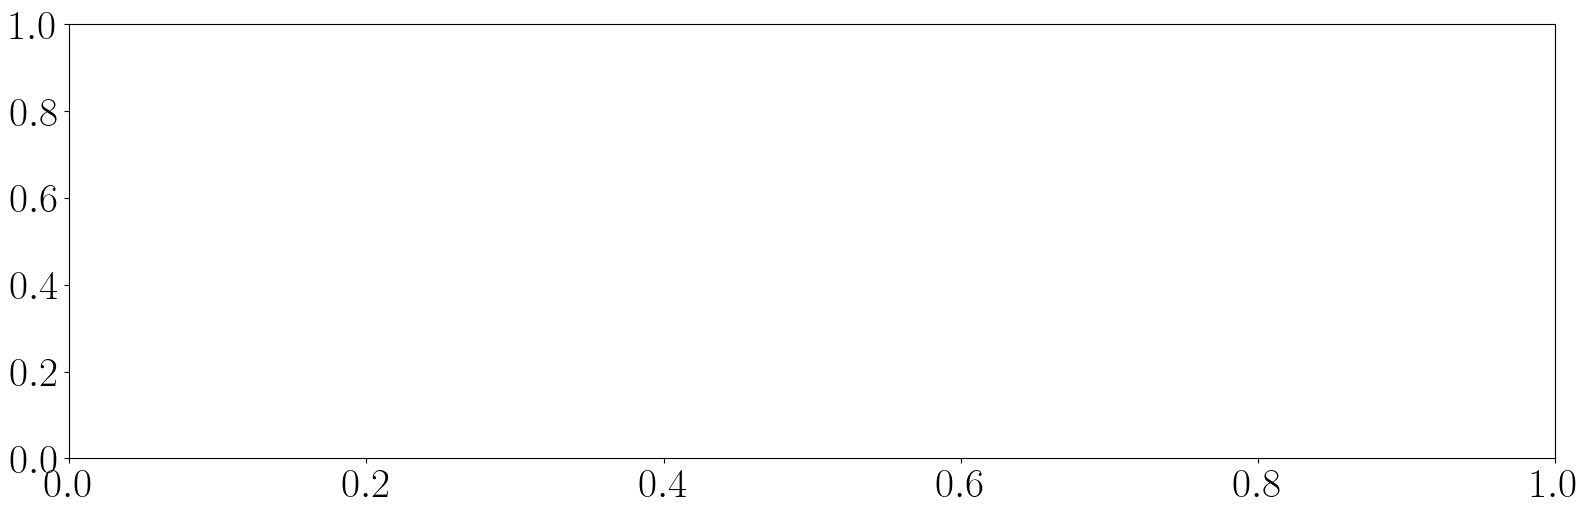

In [11]:
# Angle of each mode
plt.figure()
for m in range(3):
    plt.plot(f, thetam[:, m], color=color(m), label=fr"$\theta_{m+1}$")

plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$\theta_m$" + " [°]")
# Set grid
plt.grid()
# Tikz every 10 Hz
plt.xticks(np.arange(10, 50 + 1, 10))

In [ ]:
# # Plot modal functions
# f_plot = 50
# # krm, kzm, cpm, _, thetam = pekeris_modes(f_plot, c_water, c_sediment, rho_water, rho_sediment, depth)

# z = np.linspace(0, 150, 1000)
# phi_m = pekeris_modal_fct(z, f_plot, c_water, c_sediment, rho_water, rho_sediment, depth)
# plt.figure(figsize=(6, 4))
# for m in range(1, 4):

#     plt.plot(np.real(phi_m[m-1]), z)
#     plt.plot(np.imag(phi_m[m - 1]), z, color=color(m-1), linestyle="--")
# plt.gca().invert_yaxis()
# plt.title(f"f = {f_plot} Hz")
# plt.xlabel(r"$\phi_m(z)$")
# plt.ylabel("Depth [m]")
# plt.grid()
# # plt.xlim([-0.05, 0.05])